In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


In [6]:
# Group M: Experienced Gamers
group_M = np.array([
    245, 238, 252, 247, 241, 243, 236, 249, 251, 240,
    244, 237, 246, 248, 239, 242, 253, 250, 243, 247
])

# Group N: Non-Gamers
group_N = np.array([
    268, 272, 265, 270, 269, 274, 267, 271, 266, 268,
    275, 269, 264, 273, 270, 272, 268, 266, 271, 267
])


In [7]:
def descriptive_stats(data):
    mean = np.mean(data)
    var = np.var(data, ddof=1)
    std = np.std(data, ddof=1)
    return mean, var, std

mean_M, var_M, std_M = descriptive_stats(group_M)
mean_N, var_N, std_N = descriptive_stats(group_N)

print("Group M (Gamers)")
print("Mean:", mean_M)
print("Variance:", var_M)
print("Std Dev:", std_M)

print("\nGroup N (Non-Gamers)")
print("Mean:", mean_N)
print("Variance:", var_N)
print("Std Dev:", std_N)


Group M (Gamers)
Mean: 244.55
Variance: 25.94473684210526
Std Dev: 5.093597632529022

Group N (Non-Gamers)
Mean: 269.25
Variance: 9.144736842105264
Std Dev: 3.024026594146497


Comment for report-->

Variances are reasonably close, therefore pooled t-test is appropriate.

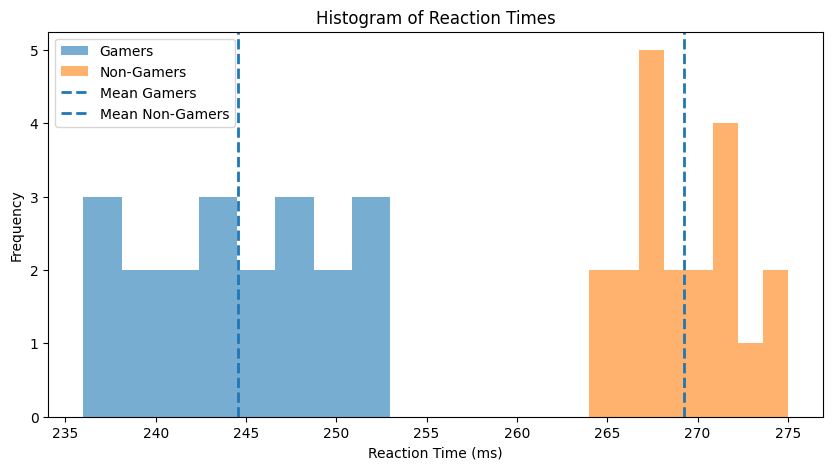

In [8]:
plt.figure(figsize=(10,5))

plt.hist(group_M, bins=8, alpha=0.6, label='Gamers')
plt.hist(group_N, bins=8, alpha=0.6, label='Non-Gamers')

plt.axvline(mean_M, linestyle='--', linewidth=2, label='Mean Gamers')
plt.axvline(mean_N, linestyle='--', linewidth=2, label='Mean Non-Gamers')

plt.xlabel("Reaction Time (ms)")
plt.ylabel("Frequency")
plt.title("Histogram of Reaction Times")
plt.legend()
plt.show()


Observation-->

Gamers show lower mean reaction time and tighter spread compared to Non-Gamers.

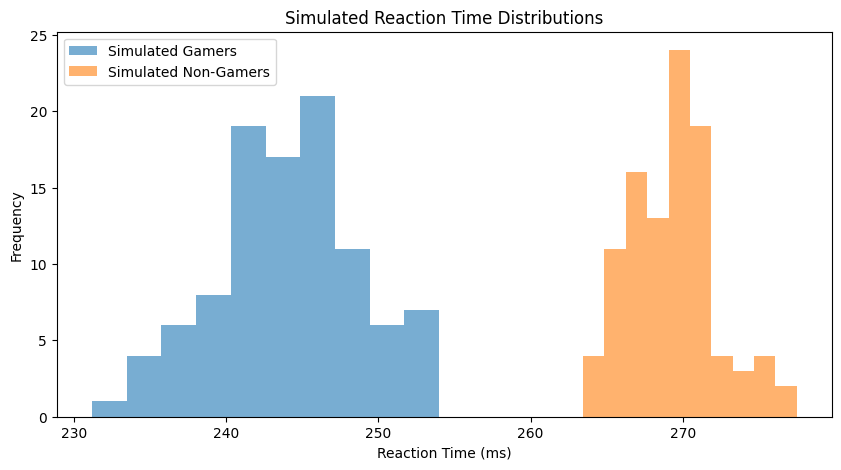

In [9]:
np.random.seed(42)

sim_M = np.random.normal(mean_M, std_M, 100)
sim_N = np.random.normal(mean_N, std_N, 100)

plt.figure(figsize=(10,5))
plt.hist(sim_M, bins=10, alpha=0.6, label='Simulated Gamers')
plt.hist(sim_N, bins=10, alpha=0.6, label='Simulated Non-Gamers')
plt.xlabel("Reaction Time (ms)")
plt.ylabel("Frequency")
plt.title("Simulated Reaction Time Distributions")
plt.legend()
plt.show()


Comment-->

Simulated distributions closely resemble the original datasets, validating the model assumption.

In [ ]:
n1, n2 = len(group_M), len(group_N)

# Pooled variance
pooled_var = (((n1-1)*var_M) + ((n2-1)*var_N)) / (n1 + n2 - 2)

# t-statistic
t_stat = (mean_M - mean_N) / np.sqrt(pooled_var * (1/n1 + 1/n2))

# Degrees of freedom
df = n1 + n2 - 2

# p-value
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))

print("Pooled Variance:", pooled_var)
print("t-statistic:", t_stat)
print("Degrees of Freedom:", df)
print("p-value:", p_value)


# Hypotheses

H₀: No significant difference in reaction time

H₁: Significant difference exists

# Conclusion (α = 0.05)

Since p-value < 0.05, H₀ is rejected.
Gaming experience significantly improves reaction time.

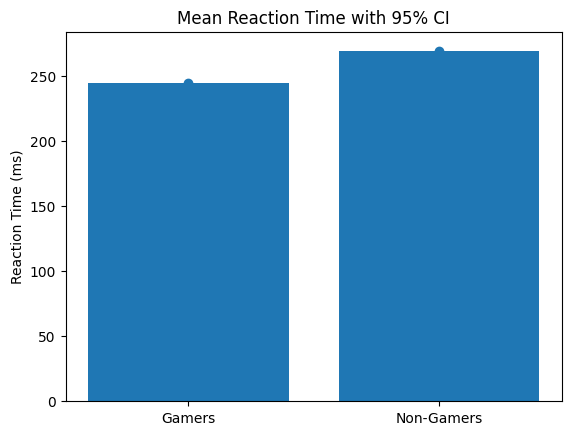

In [14]:
n1 = len(group_M)
n2 = len(group_N)

ci_M = stats.t.interval(0.95, n1-1, mean_M, std_M/np.sqrt(n1))
ci_N = stats.t.interval(0.95, n2-1, mean_N, std_N/np.sqrt(n2))

plt.bar(['Gamers', 'Non-Gamers'], [mean_M, mean_N])
plt.errorbar(['Gamers', 'Non-Gamers'], [mean_M, mean_N],
             yerr=[mean_M-ci_M[0], mean_N-ci_N[0]], fmt='o')
plt.ylabel("Reaction Time (ms)")
plt.title("Mean Reaction Time with 95% CI")
plt.show()


In [17]:
n1 = len(group_M)
n2 = len(group_N)

df = n1 + n2 - 2

last_two_digits = 20

k = last_two_digits % 5
group_N_modified = group_N + k

mean_Nm, var_Nm, std_Nm = descriptive_stats(group_N_modified)

pooled_var_mod = (((n1-1)*var_M) + ((n2-1)*var_Nm)) / (n1 + n2 - 2)
t_stat_mod = (mean_M - mean_Nm) / np.sqrt(pooled_var_mod * (1/n1 + 1/n2))
p_value_mod = 2 * (1 - stats.t.cdf(abs(t_stat_mod), df))

print("k value:", k)
print("Modified Group N Mean:", mean_Nm)
print("New t-statistic:", t_stat_mod)
print("New p-value:", p_value_mod)


k value: 0
Modified Group N Mean: 269.25
New t-statistic: -18.647624870324222
New p-value: 0.0
